In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [4]:
import pandas as pd

df = pd.read_json(
    "../data/raw/ember2018/train_features_4.jsonl",
    lines=True
)

print(df.shape)
df.head()

(132182, 14)


,sha256,md5,appeared,label,avclass,histogram,byteentropy,strings,general,header,section,imports,exports,datadirectories
0,53438728e934682c7b5fedb4293b72343a63725fc9da98...,aa4f1e6058bb424d978fb4d086de7a13,2018-07,0,,"[2730, 476, 210, 325, 316, 156, 409, 112, 91, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 228, 'avlength': 19.96052631578...","{'size': 20200, 'vsize': 32768, 'has_debug': 0...","{'coff': {'timestamp': 1519283807, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...",{'mscoree.dll': ['_CorDllMain']},[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
1,5dd444ade09050ed2e967d99f098ea4d686b5167d4da92...,eecee9107f59ff9ee39db19d50440c0a,2018-07,0,,"[117144, 21704, 6004, 5271, 9773, 2146, 2316, ...","[50209, 472, 36, 22, 16, 35, 38, 11, 30, 32, 5...","{'numstrings': 2360, 'avlength': 12.4059322033...","{'size': 827088, 'vsize': 827392, 'has_debug':...","{'coff': {'timestamp': 1530654598, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...","{'KERNEL32.dll': ['GetCurrentProcessId', 'Quer...","[CreateDocContext, CreateInstalledObjectsInfo,...","[{'name': 'EXPORT_TABLE', 'size': 6708, 'virtu..."
2,6440bca3a0ef1bbe6a5be65311c36038c6407343e1b9f5...,ce134828c0040127ca8cb00618ebc43e,2018-07,1,gamarue,"[111210, 1021, 699, 747, 947, 521, 486, 640, 1...","[4096, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 270, 'avlength': 8.355555555555...","{'size': 290816, 'vsize': 315392, 'has_debug':...","{'coff': {'timestamp': 1338904395, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...","{'MSVBVM60.DLL': ['MethCallEngine', 'ordinal55...",[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
3,4abdee311eed087a722d0035a68ca167d3778b9ae01639...,bf67d5a775e6902d0285a465a69cf8cc,2018-07,1,flystudio,"[238339, 14910, 7550, 9018, 14817, 5231, 3933,...","[28574, 1, 1, 1, 20, 1, 4, 7, 11, 2, 0, 4, 3, ...","{'numstrings': 3753, 'avlength': 12.7295496935...","{'size': 1048214, 'vsize': 1245184, 'has_debug...","{'coff': {'timestamp': 1523381808, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...","{'WINMM.dll': ['midiStreamOut', 'midiOutPrepar...",[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
4,101fa3989bc74afc184062ff1d157767ad06284075dfa3...,e111543ada51fc6315ae33cae9244894,2018-07,0,,"[2676, 32, 14, 6, 25, 1, 3, 3, 2, 2, 16, 1, 4,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 8, 'avlength': 18.875, 'printab...","{'size': 4608, 'vsize': 12288, 'has_debug': 1,...","{'coff': {'timestamp': 0, 'machine': 'I386', '...","{'entry': '', 'sections': [{'name': '.rdata', ...",{},[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."


In [5]:
df.tail()

,sha256,md5,appeared,label,avclass,histogram,byteentropy,strings,general,header,section,imports,exports,datadirectories
132177,166ecdc236ef8b23734e0300126c77f76520156e49d863...,51dc49cc349722aef22befb8cd9ff431,2018-08,1,dealply,"[5915, 2312, 1926, 2040, 2123, 1641, 2026, 189...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 1896, 'avlength': 6.35812236286...","{'size': 320000, 'vsize': 724992, 'has_debug':...","{'coff': {'timestamp': 1379080368, 'machine': ...","{'entry': 'UPX0', 'sections': [{'name': 'UPX0'...","{'KERNEL32.DLL': ['LoadLibraryA'], 'advapi32.d...",[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
132178,08395965e9ade417329d50b979536c5748ada85d45eba6...,9bb8241bf591de1748b32d24c8acbb4c,2018-08,-1,black,"[28410, 9307, 9080, 9980, 9996, 9227, 9589, 88...","[10240, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","{'numstrings': 10809, 'avlength': 5.7714867240...","{'size': 2316800, 'vsize': 5103616, 'has_debug...","{'coff': {'timestamp': 1533124666, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...","{'KERNEL32.dll': ['GetStdHandle', 'GetCurrentP...","[f\xeeF\x86`\x87\x9c{\x94H\x90 O\xcc\x85""\xd...","[{'name': 'EXPORT_TABLE', 'size': 3151, 'virtu..."
132179,7a4190472c50ac88919867a06b215e705ff20d669db50d...,a7f45a17347f0bb0fd5c9e187f44e11d,2018-08,0,,"[27792, 1886, 578, 517, 1176, 376, 166, 156, 8...","[10240, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","{'numstrings': 1140, 'avlength': 44.9684210526...","{'size': 155648, 'vsize': 155648, 'has_debug':...","{'coff': {'timestamp': 1268840404, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...",{'ngefc.dll': ['?copyTo@RegistryKey@efc@@QAEXA...,[??0?$StackReference@VRegistryKey@efc@@@efc@@Q...,"[{'name': 'EXPORT_TABLE', 'size': 39341, 'virt..."
132180,8386870afc15ca65f1291662e544358fbe3b25327d07d4...,84bd0a1c42cc488f5e4ba00204fd7825,2018-08,0,,"[3219, 169, 128, 83, 101, 34, 56, 28, 41, 21, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 97, 'avlength': 11.639175257731...","{'size': 6656, 'vsize': 32768, 'has_debug': 0,...","{'coff': {'timestamp': 1407749595, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...",{'mscoree.dll': ['_CorDllMain']},[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
132181,fef41ef17a983e0d1fcaa256b92ccbb8b329d96e7c1fe2...,6329b2c0fca1b63014fb45ff7b23056f,2018-08,1,farfli,"[84723, 8529, 3245, 6890, 5366, 2832, 1488, 21...","[12279, 0, 0, 0, 1, 0, 6, 2, 0, 0, 0, 0, 0, 0,...","{'numstrings': 1279, 'avlength': 137.408131352...","{'size': 659757, 'vsize': 970752, 'has_debug':...","{'coff': {'timestamp': 1315479401, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...","{'KERNEL32.DLL': ['WinExec'], 'ADVAPI32.dll': ...",[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 132182 entries, 0 to 132181
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   sha256           132182 non-null  str   
 1   md5              132182 non-null  str   
 2   appeared         132182 non-null  str   
 3   label            132182 non-null  int64 
 4   avclass          132182 non-null  str   
 5   histogram        132182 non-null  object
 6   byteentropy      132182 non-null  object
 7   strings          132182 non-null  object
 8   general          132182 non-null  object
 9   header           132182 non-null  object
 10  section          132182 non-null  object
 11  imports          132182 non-null  object
 12  exports          132182 non-null  object
 13  datadirectories  132182 non-null  object
dtypes: int64(1), object(9), str(4)
memory usage: 14.1+ MB


In [7]:
df.dtypes

sha256                str
md5                   str
appeared              str
label               int64
avclass               str
histogram          object
byteentropy        object
strings            object
general            object
header             object
section            object
imports            object
exports            object
datadirectories    object
dtype: object

In [8]:
missing = df.isnull().sum()
missing = missing[missing > 0]

print(missing)

Series([], dtype: int64)


In [9]:
print(df["label"].value_counts())

label
 0    48433
 1    48413
-1    35336
Name: count, dtype: int64


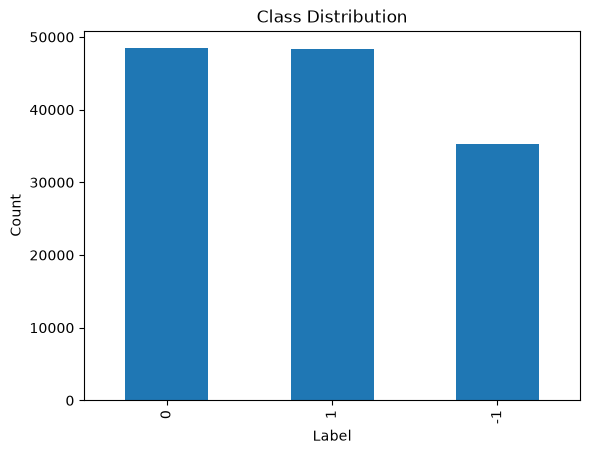

In [10]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [11]:
df.describe()

,label
count,132182.000000
mean,0.098932
std,0.789814
min,-1.000000
25%,-1.000000
50%,0.000000
75%,1.000000
max,1.000000


In [12]:
print(df.memory_usage(deep=True).sum() / 1024**2, "MB")

816.5424938201904 MB


In [13]:
print(df.columns.tolist())

['sha256', 'md5', 'appeared', 'label', 'avclass', 'histogram', 'byteentropy', 'strings', 'general', 'header', 'section', 'imports', 'exports', 'datadirectories']


In [14]:
numeric_cols = df.select_dtypes(include="number").columns
print(numeric_cols)

Index(['label'], dtype='str')


In [15]:
for col in df.columns:
    print(col)

sha256
md5
appeared
label
avclass
histogram
byteentropy
strings
general
header
section
imports
exports
datadirectories


In [16]:
import pandas as pd
import os

os.makedirs("../reports/summaries", exist_ok=True)

summary = pd.DataFrame({
    "Dataset": ["train_features_4"],
    "Rows": [df.shape[0]],
    "Columns": [df.shape[1]],
    "Missing Values": [df.isnull().sum().sum()],
    "Duplicate SHA256": [df["sha256"].duplicated().sum()],
    "Memory (MB)": [round(df.memory_usage(deep=True).sum()/(1024**2), 2)],
    "Malware Samples": [(df["label"] == 1).sum()],
    "Benign Samples": [(df["label"] == 0).sum()],
    "Unknown Samples": [(df["label"] == -1).sum()]
})

summary.to_csv("../reports/summaries/train_4_summary.csv", index=False)

print("Summary Saved!")

Summary Saved!
